In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set seeds for strict reproducibility
np.random.seed(1924)
tf.random.set_seed(1924)

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def plot_history(history, title=""):
    """Plot training and validation loss and accuracy over epochs."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    if title:
        fig.suptitle(title)
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.legend()
    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

In [10]:
# ==========================================
# TASK 1: IMPORTING AND METADATA INSPECTION
# ==========================================
# 1. Load the dataset into a Pandas DataFrame
# Ensure 'gamesData.csv' is in the same folder as your PyCharm Jupyter Notebook
file_path = 'gamesData.csv'
df = pd.read_csv(file_path)

# 2. Separate Features (X) and Target (y)
# We drop the first column (Index) and isolate the last column (Target)
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

# 3. Inspect the Metadata (As requested by the assignment rubric)
print("--- DATASET METADATA ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("--- DATATYPES AND NULL VALUES ---")
print(df.info())

# Display the first 5 rows to visually confirm a clean import
display(df.head())

--- DATASET METADATA ---
Total Rows: 16983
Total Columns: 20

--- DATATYPES AND NULL VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            16983 non-null  int64  
 1   AUR                   16983 non-null  float64
 2   Price                 16983 non-null  float64
 3   AgeRating             16983 non-null  object 
 4   Size                  16983 non-null  float64
 5   HasSubtitle           16983 non-null  int64  
 6   InAppSum              16983 non-null  float64
 7   InAppMin              16983 non-null  float64
 8   InAppMax              16983 non-null  float64
 9   InAppCount            16983 non-null  int64  
 10  InAppAvg              16983 non-null  float64
 11  descriptionTermCount  16983 non-null  int64  
 12  DevType               16983 non-null  object 
 13  LanguagesCount        169

,Unnamed: 0,AUR,Price,AgeRating,Size,HasSubtitle,InAppSum,InAppMin,InAppMax,InAppCount,InAppAvg,descriptionTermCount,DevType,LanguagesCount,EngSupported,GenreCount,months,monthsSinceUpdate,GameFree,Ratings
0,1,4.0,2.99,4+,15853568.0,0,0.0,0.0,0.0,0,0.0,263,Professional,17,1,2,7,29,1,1
1,2,3.5,1.99,4+,12328960.0,0,0.0,0.0,0.0,0,0.0,204,Newbie,1,1,2,7,17,1,1
2,3,3.0,0.00,4+,674816.0,0,0.0,0.0,0.0,0,0.0,97,Newbie,1,1,2,7,25,1,1
3,4,3.5,0.00,4+,21552128.0,0,0.0,0.0,0.0,0,0.0,272,Professional,17,1,2,7,29,1,1
4,5,3.5,2.99,4+,34689024.0,0,0.0,0.0,0.0,0,0.0,365,Newbie,15,1,3,7,15,1,0


In [11]:
# ==========================================
# TASK 2: DATASET PARTITIONING
# ==========================================
# We split the data: 80% for training the model, 20% for testing its accuracy.
# We use the X (features) and y (target) that we isolated in Task 1.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1924) # Strict seed to ensure the exact same split every time

# Verify the partitioning
print("--- DATA PARTITIONING RESULTS ---")
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test):   {X_test.shape}")
print(f"Training Target Shape (y_train):   {y_train.shape}")
print(f"Testing Target Shape (y_test):     {y_test.shape}")

--- DATA PARTITIONING RESULTS ---
Training Features Shape (X_train): (13586, 18)
Testing Features Shape (X_test):   (3397, 18)
Training Target Shape (y_train):   (13586,)
Testing Target Shape (y_test):     (3397,)


In [13]:
# ==========================================
# TASK 3: PREPROCESSING & SCALING
# ==========================================

# 1. Handle Categorical Features (One-Hot Encoding)
# Neural networks cannot read text. We must convert text columns into binary (1s and 0s).
X_train_encoded = pd.get_dummies(X_train, dtype=int)
X_test_encoded = pd.get_dummies(X_test, dtype=int)

# Crucial Safety Net: Ensure the test set has the exact same columns as the train set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


# 2. Scale Numeric Attributes
# We use MinMaxScaler to force all numerical values into a [0, 1] range.
scaler = MinMaxScaler()
numeric_cols = ["AUR", "Price", "Size", "InAppSum", "InAppMin",
                "InAppMax", "InAppCount", "InAppAvg", "descriptionTermCount",
                "LanguagesCount", "GenreCount", "months", "monthsSinceUpdate"]

# Fit the scaler on the training data ONLY (to prevent data leakage), then transform both sets
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols]  = scaler.transform(X_test_encoded[numeric_cols])


# 3. Target Encoding (Matching the Session 1 Workshop)
# The original targets are [-1, 0, 1]. Keras expects categories starting from 0.
# We shift them by +1 so they become [0, 1, 2].
y_train_mapped = y_train + 1
y_test_mapped = y_test + 1

# Convert integer targets into one-hot arrays (e.g., 2 becomes [0, 0, 1])
y_train_cat = to_categorical(y_train_mapped, num_classes=3)
y_test_cat = to_categorical(y_test_mapped, num_classes=3)

# Verification
print("--- PREPROCESSING COMPLETE ---")
print(f"Final Training Features Shape: {X_train_encoded.shape}")
print(f"Final Testing Features Shape:  {X_test_encoded.shape}")
print(f"y_train_cat:  {y_train_cat.shape}")
print(f"y_test_cat:  {y_test_cat.shape}")

--- PREPROCESSING COMPLETE ---
Final Training Features Shape: (13586, 20)
Final Testing Features Shape:  (3397, 20)
y_train_cat:  (13586, 3)
y_test_cat:  (3397, 3)


--- MODEL ARCHITECTURE ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 32)                672       
                                                                 
 Hidden_Layer_2 (Dense)      (None, 16)                528       
                                                                 
 Output_Layer (Dense)        (None, 3)                 51        
                                                                 
Total params: 1251 (4.89 KB)
Trainable params: 1251 (4.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

--- BEGINNING MODEL TRAINING ---
Epoch 1/50
340/340 [==============================] - 2s 1ms/step - loss: 0.5411 - accuracy: 0.7551 - val_loss: 0.3080 - val_accuracy: 0.8385
Epoch 2/50
340/340 [==============================] - 0s 1ms/step - loss: 0.2866 - ac

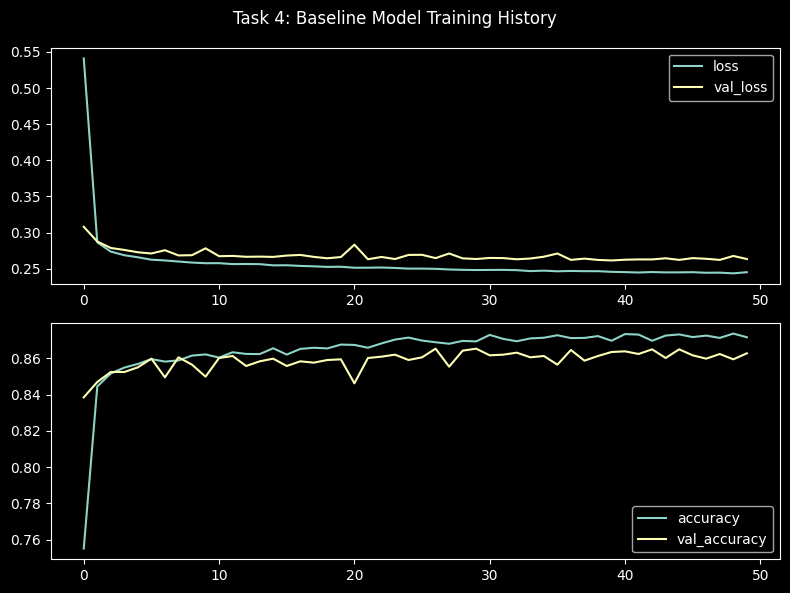

Baseline Model - Test Loss: 0.2497, Test Accuracy: 0.8705


In [14]:
# ==========================================
# TASK 4: BUILD, COMPILE, AND FIT
# ==========================================

# 1. Convert DataFrames to Pure Matrices (Numpy Arrays)
# Your rubric strictly warns: "matrices need to be organized properly...
# and stripped of all additional metadata such as column names."
X_train_matrix = X_train_encoded.to_numpy()
X_test_matrix = X_test_encoded.to_numpy()

input_dim = X_train_matrix.shape[1] # This dynamically grabs the '20' features

# 2. Build the Neural Network Architecture (Sequential API)
# This is our "Baseline" model before we tune parameters in Task 6
baseline_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
    layers.Dense(16, activation='relu', name="Hidden_Layer_2"),
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- MODEL ARCHITECTURE ---")
baseline_model.summary()

# 3. Compile the Model
# We use 'rmsprop' because your professor heavily favors it in session_1.py and session_2.py
baseline_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the Model
print("\n--- BEGINNING MODEL TRAINING ---")
history_baseline = baseline_model.fit(
    X_train_matrix, y_train_cat,
    epochs=50,             # Running 50 epochs to see where it plateaus
    batch_size=32,
    validation_split=0.2,  # Holds back 20% of the training data purely for mid-training validation
    verbose=1              # Shows the progress bar
)

# 5. Evaluate and Visualize
print("\n--- MODEL EVALUATION ---")
# Call the exact helper function we defined in Cell 1
plot_history(history_baseline, title="Task 4: Baseline Model Training History")

# Final Test Set Evaluation (ONLY NOW WE USE TEST DATA)
test_loss, test_accuracy = baseline_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Baseline Model - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

--- TUNED MODEL ARCHITECTURE ---
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 64)                1344      
                                                                 
 Dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 Hidden_Layer_2 (Dense)      (None, 32)                2080      
                                                                 
 Dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 Hidden_Layer_3 (Dense)      (None, 16)                528       
                                                                 
 Output_Layer (Dense)        (None, 3)                 51        
                                                                 
Total params: 4003 (1

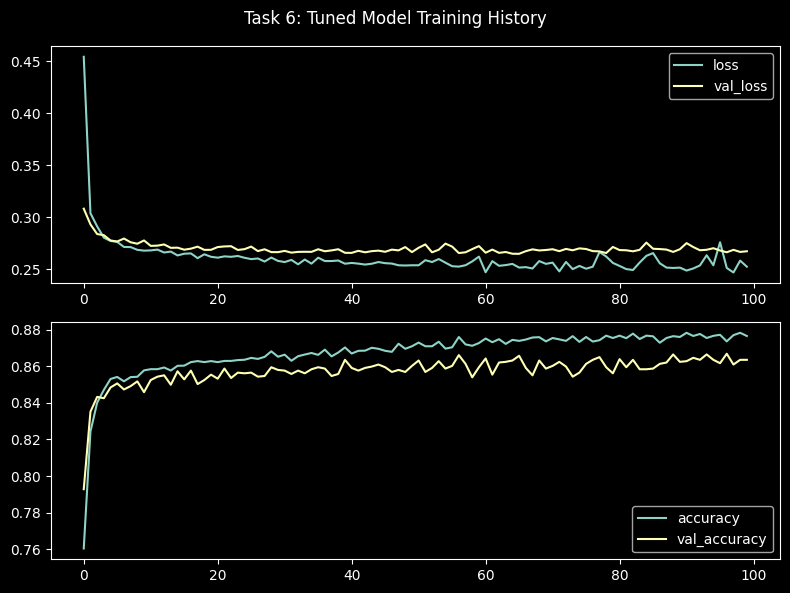

Tuned Model - Test Loss: 0.2594, Test Accuracy: 0.8743


In [25]:
# ==========================================
# TASK 6: PARAMETER TUNING
# ==========================================

# 1. Build the Tuned Architecture (3-Layer Network with Dropout)
# We are expanding from 2 hidden layers to 3, and adding Dropout regularization.
tuned_model = keras.Sequential([
    # Hidden Layer 1: Expanded to 64 neurons to capture more initial patterns
    layers.Dense(64, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
    layers.Dropout(0.3, name="Dropout_1"), # Randomly turns off 30% of neurons

    # Hidden Layer 2: Funneling down to 32 neurons
    layers.Dense(32, activation='relu', name="Hidden_Layer_2"),
    layers.Dropout(0.2, name="Dropout_2"), # Randomly turns off 20% of neurons

    # Hidden Layer 3: Final feature extraction
    layers.Dense(16, activation='relu', name="Hidden_Layer_3"),

    # Output Layer
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- TUNED MODEL ARCHITECTURE ---")
tuned_model.summary()

# 2. Compile the Model
# We stick with rmsprop to keep the comparison scientifically fair against the baseline
tuned_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the Model
print("\n--- BEGINNING TUNED MODEL TRAINING ---")
history_tuned = tuned_model.fit(
    X_train_matrix, y_train_cat,
    epochs=100,            # Doubling epochs to give the more complex model a chance to learn
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate and Visualize
print("\n--- TUNED MODEL EVALUATION ---")
plot_history(history_tuned, title="Task 6: Tuned Model Training History")

# 5. Final Exam (Test Set)
test_loss_tuned, test_acc_tuned = tuned_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Tuned Model - Test Loss: {test_loss_tuned:.4f}, Test Accuracy: {test_acc_tuned:.4f}")

In [26]:
# ==========================================
# TASK 7: TRADITIONAL MODEL COMPARISON (EXPANDED)
# ==========================================
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("--- TRAINING TRADITIONAL MODELS ---")

# Dictionary to store results for a clean printout at the end
results = {}

# 1. Random Forest (Tree-based Ensemble)
rf = RandomForestClassifier(n_estimators=100, random_state=1924)
start_time = time.time()
rf.fit(X_train_matrix, y_train_mapped)
rf_time = time.time() - start_time
rf_acc = accuracy_score(y_test_mapped, rf.predict(X_test_matrix))
results['Random Forest'] = {'Accuracy': rf_acc, 'Time': rf_time}

# 2. Naive Bayes (Probability-based)
nb = GaussianNB()
start_time = time.time()
nb.fit(X_train_matrix, y_train_mapped)
nb_time = time.time() - start_time
nb_acc = accuracy_score(y_test_mapped, nb.predict(X_test_matrix))
results['Naive Bayes'] = {'Accuracy': nb_acc, 'Time': nb_time}

# 3. K-Nearest Neighbors (Distance-based)
knn = KNeighborsClassifier(n_neighbors=5)
start_time = time.time()
knn.fit(X_train_matrix, y_train_mapped)
knn_time = time.time() - start_time
knn_acc = accuracy_score(y_test_mapped, knn.predict(X_test_matrix))
results['K-Nearest Neighbors'] = {'Accuracy': knn_acc, 'Time': knn_time}

# 4. Support Vector Machine (Boundary-based)
svm = SVC(kernel='rbf', random_state=1924)
start_time = time.time()
svm.fit(X_train_matrix, y_train_mapped)
svm_time = time.time() - start_time
svm_acc = accuracy_score(y_test_mapped, svm.predict(X_test_matrix))
results['Support Vector Machine'] = {'Accuracy': svm_acc, 'Time': svm_time}

# ==========================================
# PRINT FINAL BENCHMARKS
# ==========================================
print("\n--- FINAL BENCHMARK RESULTS ---")
print(f"{'Model':<25} | {'Test Accuracy':<15} | {'Training Time (sec)'}")
print("-" * 65)
for model_name, metrics in results.items():
    print(f"{model_name:<25} | {metrics['Accuracy']:.4f}          | {metrics['Time']:.4f}")

# Assuming test_acc_tuned is still in memory from Task 6
print("-" * 65)
print(f"{'Neural Network (Task 6)':<25} | {test_acc_tuned:.4f}          | (Multiple Epochs)")

--- TRAINING TRADITIONAL MODELS ---

--- FINAL BENCHMARK RESULTS ---
Model                     | Test Accuracy   | Training Time (sec)
-----------------------------------------------------------------
Random Forest             | 0.8805          | 1.4494
Naive Bayes               | 0.8413          | 0.0504
K-Nearest Neighbors       | 0.8449          | 0.0283
Support Vector Machine    | 0.8605          | 1.5858
-----------------------------------------------------------------
Neural Network (Task 6)   | 0.8743          | (Multiple Epochs)
